<a href="https://colab.research.google.com/github/kalyaninivant/Digital_Image_Processing-/blob/main/Assignment_6%267.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Read images
img_point = cv2.imread('/content/Point.tif', 0)
img_line = cv2.imread('/content/line.tif', 0)
img_thresh = cv2.imread('/content/thresholding .tif', 0)
img_edge = cv2.imread('/content/edge.tif', 0)

# # Point Detection - in this the masks computes with the image pixel to detect the points same in the line detection;
# #added threshold to the point detection for highlighting the point
# kernel_point = np.array([[-1,-1,-1],
#                          [-1, 8,-1],
#                          [-1,-1,-1]])
# point = cv2.filter2D(img_point, -1, kernel_point)
# ret, point_thresh = cv2.threshold(point, 10, 255, cv2.THRESH_BINARY) #threshold for point detection is 90% of the highest absolute pixel value of the image

# Apply mask
point = cv2.filter2D(img_point, -1, kernel_point)

# Convert to absolute
point_abs = np.abs(point)

# Find max absolute value
max_val = np.max(point_abs)

# Compute threshold (90%)
threshold_value = 0.98 * max_val

# Apply threshold
ret, point_thresh = cv2.threshold(point_abs.astype(np.uint8), threshold_value, 255, cv2.THRESH_BINARY)

# Line Detection
kernel_line = np.array([[-1,-1,-1],
                        [ 2, 2, 2],
                        [-1,-1,-1]])
line = cv2.filter2D(img_line, -1, kernel_line)

#  Global Threshold - in this the image is 1st converted to binary and which converts the pixels into binary values depending on their grayscale like if threshold is decided then based on that if it is lower than 127 then 0 or more then 1
ret, thresh = cv2.threshold(img_thresh,127,255,cv2.THRESH_BINARY)
#initial threshold muste be chose greater than min and less than max intensity label in the image
#average intensity of the image is consider to be the good choice to select the initial threshold value

#  Edge Detection - Canny edge detection identifies sharp intensity changes in the image.
edges = cv2.Canny(img_edge,100,200)
#[Canny uses two thresholds because of a process called hysteresis thresholding:
#If gradient intensity > 200 → it is definitely an edge.
#If gradient intensity < 100 → it is discarded.
#If gradient intensity is between 100 and 200 → it is considered an edge only if it is connected to a strong edge.]
#initial threshold muste be chose greater than min and less than max intensity label in the image
#average intensity of the image is consider to be the good choice to select the initial threshold value

# Display Results
plt.figure(figsize=(10,10))

# Point detection
plt.subplot(4,2,1)
plt.title("Original Point Image")
plt.imshow(img_point, cmap='gray')
plt.axis('off')

plt.subplot(4,2,2)
plt.title("Point Detection")
plt.imshow(point, cmap='gray')
plt.axis('off')

# Line detection
plt.subplot(4,2,3)
plt.title("Original Line Image")
plt.imshow(img_line, cmap='gray')
plt.axis('off')

plt.subplot(4,2,4)
plt.title("Line Detection")
plt.imshow(line, cmap='gray')
plt.axis('off')

# Thresholding
plt.subplot(4,2,5)
plt.title("Original Threshold Image")
plt.imshow(img_thresh, cmap='gray')
plt.axis('off')

plt.subplot(4,2,6)
plt.title("Global Threshold")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

# Edge detection
plt.subplot(4,2,7)
plt.title("Original Edge Image")
plt.imshow(img_edge, cmap='gray')
plt.axis('off')

plt.subplot(4,2,8)
plt.title("Edge Detection (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.show()

NameError: name 'kernel_point' is not defined

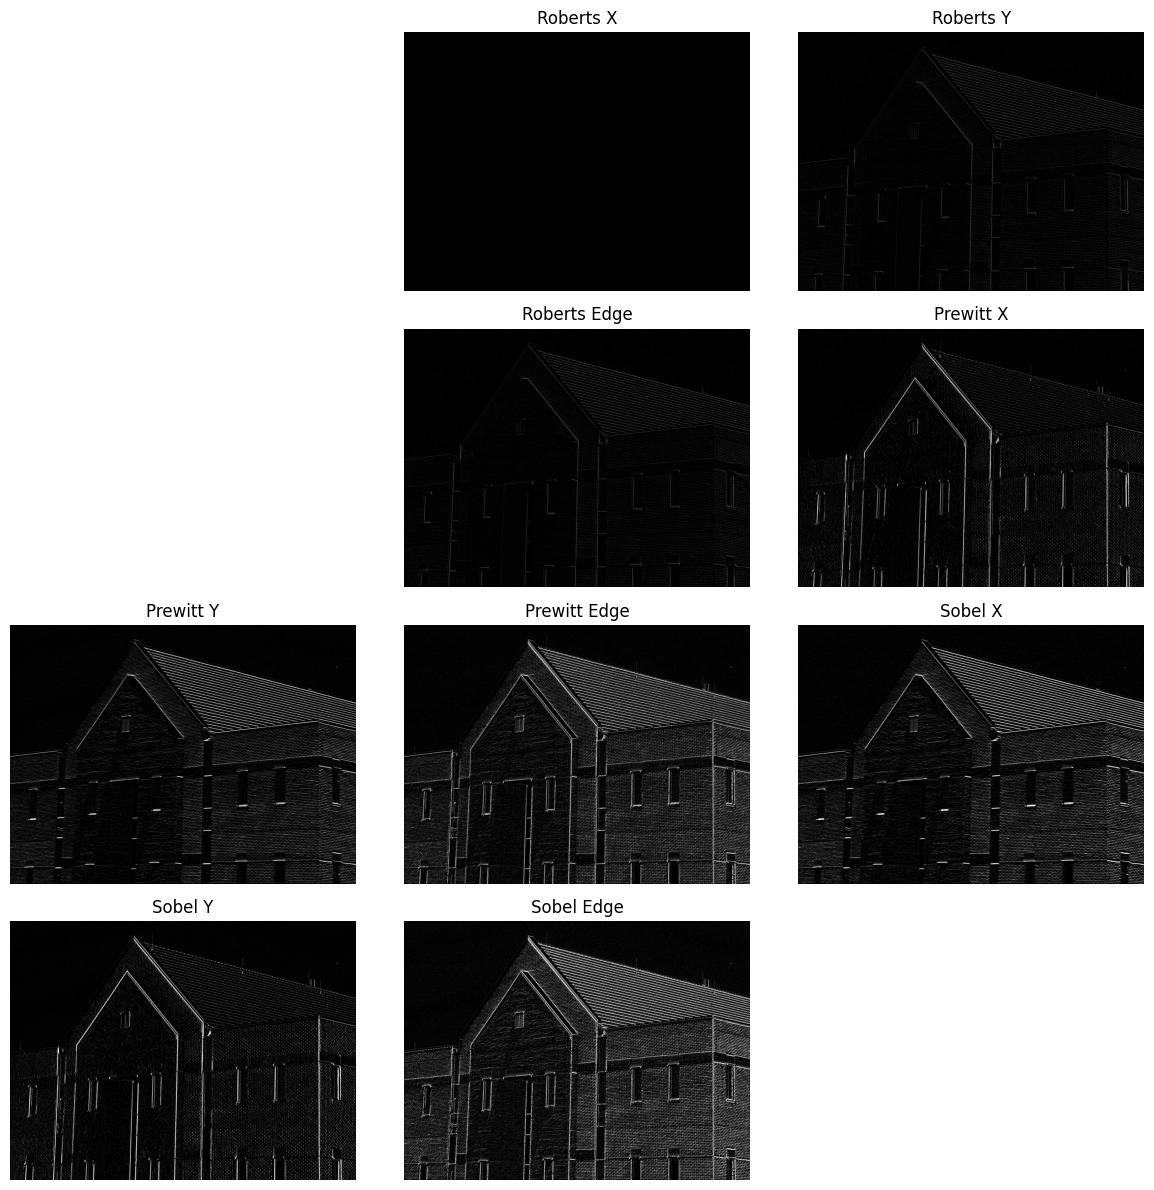

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Read image
img = cv2.imread('/content/Edge detectn.bmp',0)

#  Roberts Operator
roberts_x = np.array([[-1,0],    #this convolutes along one diagonal direction
                      [0,-1]])

roberts_y = np.array([[0,-1],  #this convolutes along the other diagonal direction
                      [1,0]])

roberts_x_img = cv2.filter2D(img,-1,roberts_x)  #for convolution
roberts_y_img = cv2.filter2D(img,-1,roberts_y)

roberts = roberts_x_img + roberts_y_img #finally both the convolution results are added


#  Prewitt Operator
prewitt_x = np.array([[-1,0,1],   #this is for vertical edge detection left - right
                      [-1,0,1],
                      [-1,0,1]])

prewitt_y = np.array([[-1,-1,-1],  #this for horizontal detects intensity changes from top to bottom
                      [0,0,0],
                      [1,1,1]])

prewitt_x_img = cv2.filter2D(img,-1,prewitt_x)  #convolution
prewitt_y_img = cv2.filter2D(img,-1,prewitt_y)

prewitt = prewitt_x_img + prewitt_y_img #this is addition of the both horizontal and vertical intensity changes



#  Sobel Operator
Sobel_x = np.array([[-1,-2,-1],
                      [-0,0,0],
                      [1,2,1]])

sobel_y = np.array([[-1,0,1],
                      [-2,0,2],
                      [-1,0,1]])

sobel_x_img = cv2.filter2D(img,-1,Sobel_x)
sobel_y_img = cv2.filter2D(img,-1,sobel_y)

Sobel = sobel_x_img + sobel_y_img


#  Display Results
plt.figure(figsize=(12,12))

# -------- ROBERTS --------
#plt.subplot(4,3,1)
#plt.title("Original")
#plt.imshow(img,cmap='gray')
#plt.axis('off')

plt.subplot(4,3,2)
plt.title("Roberts X")
plt.imshow(roberts_x_img,cmap='gray')
plt.axis('off')

plt.subplot(4,3,3)
plt.title("Roberts Y")
plt.imshow(roberts_y_img,cmap='gray')
plt.axis('off')

#plt.subplot(4,3,4)
#plt.title("Original")
#plt.imshow(img,cmap='gray')
#plt.axis('off')

plt.subplot(4,3,5)
plt.title("Roberts Edge")
plt.imshow(roberts,cmap='gray')
plt.axis('off')


# -------- PREWITT --------
plt.subplot(4,3,6)
plt.title("Prewitt X")
plt.imshow(prewitt_x_img,cmap='gray')
plt.axis('off')

plt.subplot(4,3,7)
plt.title("Prewitt Y")
plt.imshow(prewitt_y_img,cmap='gray')
plt.axis('off')

plt.subplot(4,3,8)
plt.title("Prewitt Edge")
plt.imshow(prewitt,cmap='gray')
plt.axis('off')


# -------- SOBEL --------
plt.subplot(4,3,9)
plt.title("Sobel X")
plt.imshow(sobel_x_img,cmap='gray')
plt.axis('off')

plt.subplot(4,3,10)
plt.title("Sobel Y")
plt.imshow(sobel_y_img,cmap='gray')
plt.axis('off')

plt.subplot(4,3,11)
plt.title("Sobel Edge")
plt.imshow(Sobel,cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/Log.bmp',0)

img = np.float32(img)
img = img-128

dct = cv2.dct(img)

Q = standard_matrix
quantized = np.round(dct / Q)

reconstructed = quantized * Q

idct = cv2.idct(reconstructed)

idct = idct + 128

plt.imshow(idct, cmap='gray')
plt.axis('off')





NameError: name 'standard_matrix' is not defined